# MCMC sampler

In [1]:
import sys
sys.path.append('..')

import arviz as az
import emcee
import numpy as np
import matplotlib.pyplot as plt
from corner import corner

from src.MCMC.helpers import gen_parameter_labels
from src.MCMC.posterior import log_posterior
from src.MCMC.priors import UniformPrior

from src.simulator import BurstSimulator, Model
from src.helpers import plot_posterior_samples

In [2]:
# defining the priors
def get_prior_dict(N):
    prior_dict = {
        "t0"  : UniformPrior(x_min=0,    x_max=1,   log=False, enforce_order=True, dim=N),
        "amp" : UniformPrior(x_min=10,   x_max=300, log=False,  enforce_order=False, dim=N),
        "rise": UniformPrior(x_min=1e-3, x_max=1,  log=True, enforce_order=False, dim=N),
        "skew": UniformPrior(x_min=1,    x_max=6,   log=False, enforce_order=False, dim=N)
    }
    return prior_dict

In [4]:
time = np.linspace(0, 1, 1000)

# NOTE: can change this to whichever N and inf_params you like
N = 15
inf_params = ["t0"]

amp  = [100.0 for _ in range(N)]
t0   = np.sort(np.random.rand(N))
rise = [0.03 for _ in range(N)]
skew = [5.0 for _ in range(N)]

burstparams = {
    't0'   : t0,
    'amp'  : amp,
    'rise' : rise,
    'skew' : skew
    }

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': 5.0
}

model = Model(**modelparams)
simulator = BurstSimulator(model)
x_model, simulated_counts = simulator.simulate_burst(return_model=True)

true_values = np.array([simulator.get_true(key) for key in inf_params])
true_values = true_values.flatten()

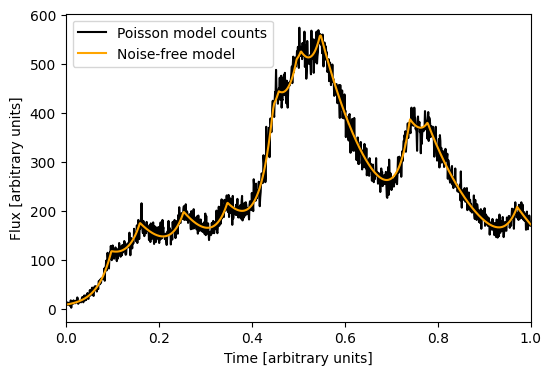

In [5]:
plt.figure(figsize=(6,4))
simulator.plot_burst()
plt.show()

In [6]:
prior_dict = get_prior_dict(N)

nwalkers = 50
ndim = len(inf_params) * N

p0 = [prior_dict[key].sample(nwalkers) for key in inf_params]
p0 = np.concatenate(p0, axis=1)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[inf_params, prior_dict, modelparams, simulated_counts])

In [7]:
# burn-in of 100 steps
burn_steps = 500
steps = 2000

state = sampler.run_mcmc(p0, burn_steps)
sampler.reset()

# correct walkers with low likelihood (otherwise likely to get stuck)
rounded_probs = 1000 * np.floor(state.log_prob / 1000)
low_prob_mask = state.log_prob < np.max(rounded_probs)

variations      = np.ones((sum(low_prob_mask), ndim)) * np.random.uniform(low=0.9, high=1.1, size=(sum(low_prob_mask), ndim))
most_likely_pos = state.coords[np.argmax(state.log_prob)]
state.coords[low_prob_mask] = most_likely_pos * variations

# burn-in with repositioned walkers 
state = sampler.run_mcmc(state, burn_steps)

sampler.reset()

# running the samples
sampler.run_mcmc(state, steps, progress=True)

100%|██████████| 2000/2000 [01:03<00:00, 31.59it/s]


State([[0.09793569 0.16270754 0.25221416 0.34579016 0.44173648 0.45045704
  0.45412386 0.49658866 0.49971575 0.54692893 0.54799079 0.73897941
  0.74270884 0.77983904 0.97034012]
 [0.09750953 0.16136946 0.25165662 0.34754238 0.44436001 0.45223159
  0.45321091 0.49937294 0.49963848 0.54344579 0.55098086 0.73693675
  0.74619008 0.77707588 0.97090668]
 [0.0974781  0.16153461 0.25288177 0.34749629 0.4423795  0.45240877
  0.45417998 0.49355023 0.50435808 0.54710929 0.54760474 0.73876383
  0.74114848 0.7802784  0.97023369]
 [0.09826825 0.16016916 0.25324111 0.34651822 0.4451732  0.45001058
  0.45621754 0.49902634 0.50126793 0.54124815 0.5527858  0.73879236
  0.74085905 0.78207788 0.97079766]
 [0.09722889 0.16030228 0.25089051 0.34764294 0.44345156 0.45138371
  0.45162645 0.49430731 0.50636214 0.54181807 0.55383573 0.74050696
  0.74133641 0.78065704 0.97201642]
 [0.09806904 0.16033497 0.25269767 0.34641107 0.44381761 0.45160295
  0.45357473 0.49641984 0.50096305 0.54464743 0.54692816 0.7385684

In [8]:
samples = sampler.get_chain(flat=True)

In [9]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)
tau = sampler.get_autocorr_time()
tau

Mean acceptance fraction: 0.360


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 15 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [168.87689375 275.69782342 188.12534943 243.93722076 274.37360376
 166.08827494 171.38016271 150.79375542 136.07806952 150.34612419
 283.73786769 136.95336534  80.31476817  78.99579591 141.54647694]

# Trace plots

[0.09832662 0.1597772  0.25380251 0.3478464  0.44502121 0.44826882
 0.45822664 0.49678771 0.50600852 0.54677451 0.5489143  0.74007632
 0.74067116 0.77813573 0.97099815]


Text(0.5, 0, 'step number')

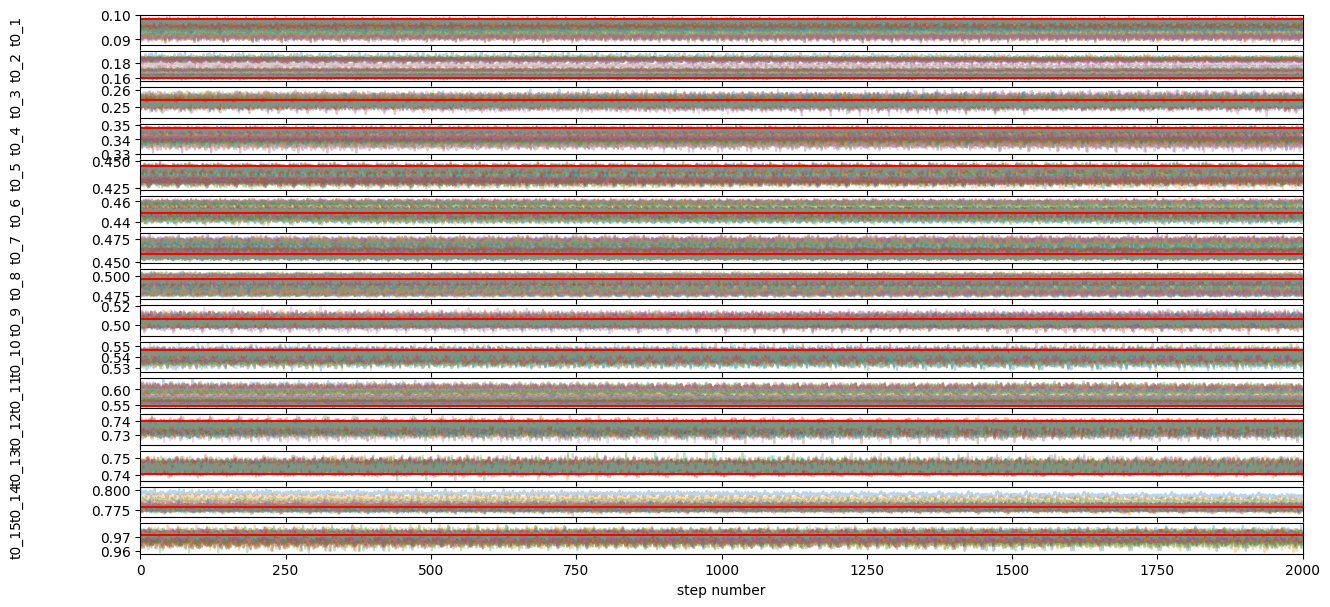

In [ ]:
fig, axes = plt.subplots(ndim, figsize=(15, 7), sharex=True)
labels = gen_parameter_labels(inf_params, N)
print(true_values)
for i in range(ndim):
    ax = axes[i]
    for w in range(nwalkers): #TODO: check if this correct, subsample walkers maybe
        ax.plot(samples[w*steps:w*steps+steps, i], "-", alpha=0.3)
    ax.set_xlim(0, len(samples)//nwalkers)
    ax.set_ylabel(labels[i])
    ax.hlines([true_values[i]], xmin=0, xmax=steps, color='red')
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

# Corner plot

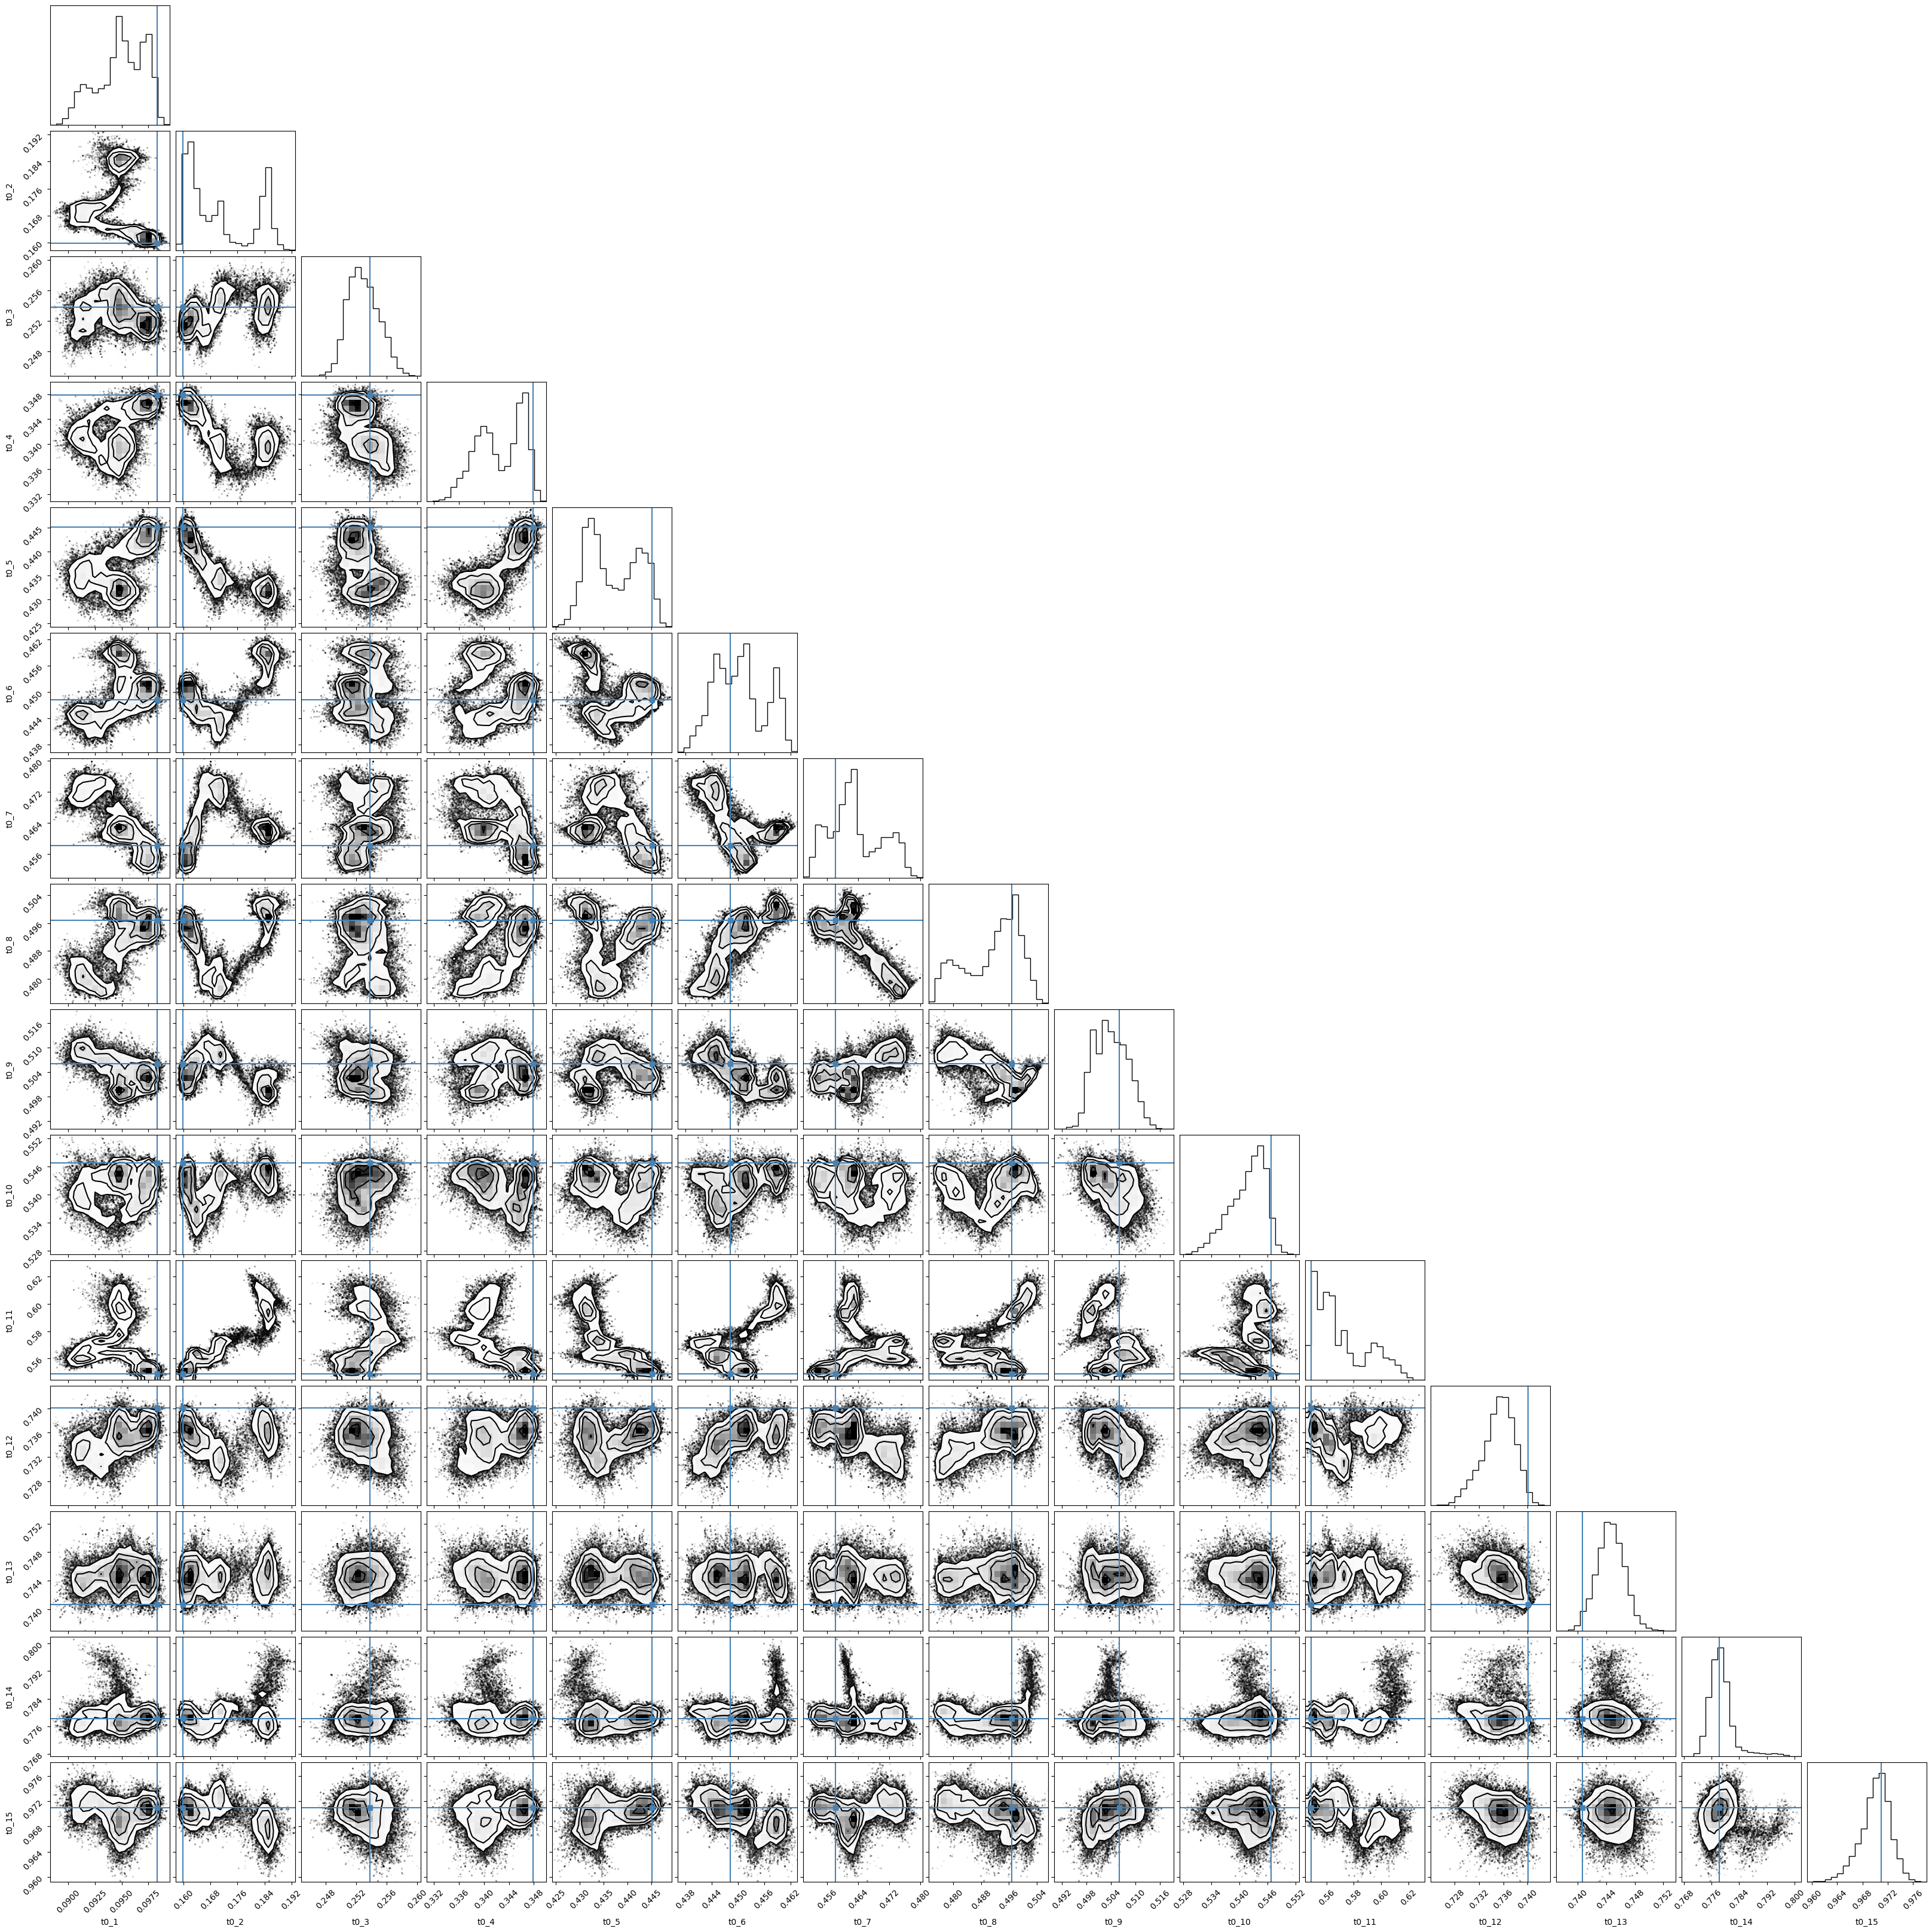

In [11]:
labels = gen_parameter_labels(inf_params, N)
samples = sampler.get_chain(flat=True)
fig = corner(samples, labels=labels, truths=true_values)

# Posterior samples

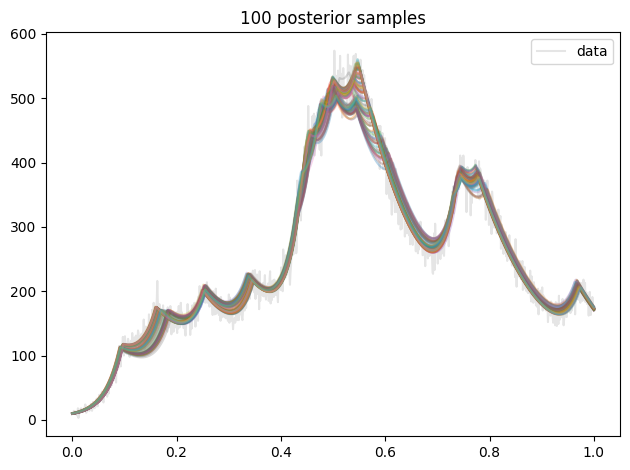

In [12]:
# Draw samples from posterior and overlay onto simulated data
N_samples = 100
plot_posterior_samples(N_samples, simulated_counts, samples, inf_params, modelparams)
plt.tight_layout()

In [13]:
inference_data = az.from_emcee(sampler, labels) 
print(az.summary(inference_data))

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
t0_1   0.095  0.002   0.091    0.098      0.000    0.000     219.0     346.0   
t0_2   0.171  0.010   0.160    0.186      0.001    0.000      78.0     364.0   
t0_3   0.253  0.002   0.250    0.257      0.000    0.000     186.0    1096.0   
t0_4   0.343  0.004   0.336    0.348      0.000    0.000      80.0     403.0   
t0_5   0.437  0.005   0.429    0.446      0.001    0.000      79.0     342.0   
t0_6   0.450  0.006   0.442    0.461      0.000    0.000     299.0     568.0   
t0_7   0.463  0.007   0.453    0.475      0.000    0.000     263.0     317.0   
t0_8   0.491  0.008   0.477    0.502      0.000    0.000     310.0     685.0   
t0_9   0.504  0.004   0.498    0.512      0.000    0.000     404.0    1043.0   
t0_10  0.542  0.004   0.534    0.547      0.000    0.000     316.0     889.0   
t0_11  0.571  0.019   0.546    0.607      0.002    0.001      85.0     323.0   
t0_12  0.735  0.003   0.730    0.740    